<a href="https://colab.research.google.com/github/namgiju/mlprog/blob/main/chapter03_ml_organized.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Chapter 03 머신러닝의 기초 — KNN / Random Forest / Logistic Regression 비교

## 1. 붓꽃 분류

# 라이브러리 불러오기


In [1]:
from sklearn import datasets, metrics
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression


# Iris 데이터 불러오기


In [2]:
iris = datasets.load_iris()
X = iris.data
y = iris.target


# 학습 데이터와 테스트 데이터 나누기


In [3]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=4)
print(X_train.shape)
print(X_test.shape)


(120, 4)
(30, 4)


# 붓꽃 클래스와 새로운 예측 데이터 설정


In [4]:
classes = {0: 'setosa', 1: 'versicolor', 2: 'virginica'}
x_new = [[3, 4, 5, 2],
         [5, 4, 2, 2]]


# 분류 모델 생성


In [5]:
models = {
    "KNN": KNeighborsClassifier(n_neighbors=6),
    "Random Forest": RandomForestClassifier(random_state=0),
    "Logistic Regression": LogisticRegression(max_iter=1000),
}


# 모델 학습 · 예측 · 성능 평가


In [6]:
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    scores = metrics.accuracy_score(y_test, y_pred)
    y_predict = model.predict(x_new)
    print(f"\n--- {name} ---")
    print("Accuracy:", scores)
    print("새 데이터 예측:", classes[y_predict[0]], ",", classes[y_predict[1]])



--- KNN ---
Accuracy: 0.9666666666666667
새 데이터 예측: versicolor , setosa

--- Random Forest ---
Accuracy: 0.9666666666666667
새 데이터 예측: virginica , setosa

--- Logistic Regression ---
Accuracy: 0.9666666666666667
새 데이터 예측: virginica , setosa


## 2. 필기체 숫자 분류 + 혼동행렬

# 라이브러리 불러오기


In [7]:
import matplotlib.pyplot as plt
from sklearn import datasets, metrics
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression


# Digits 데이터 분류 및 평가


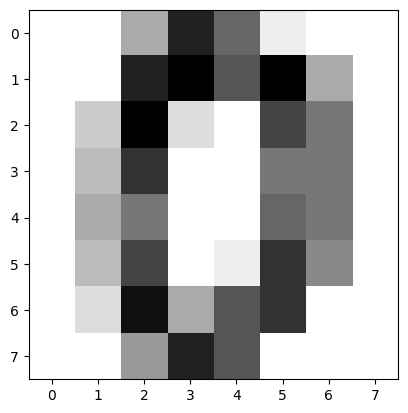


--- KNN ---
Accuracy: 0.9722222222222222


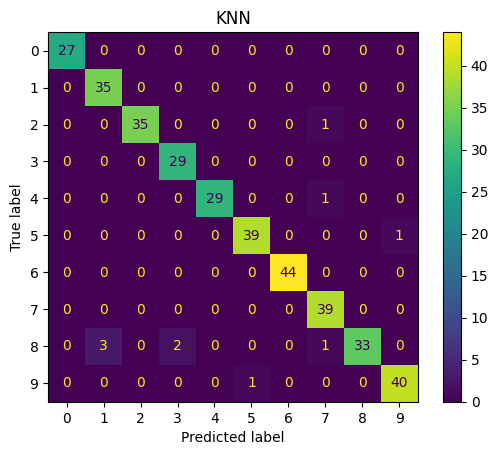

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        27
           1       0.92      1.00      0.96        35
           2       1.00      0.97      0.99        36
           3       0.94      1.00      0.97        29
           4       1.00      0.97      0.98        30
           5       0.97      0.97      0.97        40
           6       1.00      1.00      1.00        44
           7       0.93      1.00      0.96        39
           8       1.00      0.85      0.92        39
           9       0.98      0.98      0.98        41

    accuracy                           0.97       360
   macro avg       0.97      0.97      0.97       360
weighted avg       0.97      0.97      0.97       360


--- Random Forest ---
Accuracy: 0.9694444444444444


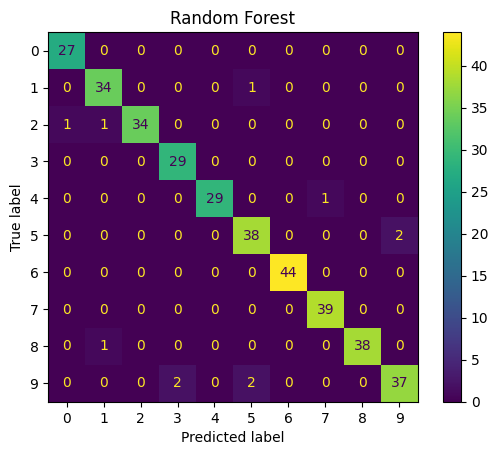

              precision    recall  f1-score   support

           0       0.96      1.00      0.98        27
           1       0.94      0.97      0.96        35
           2       1.00      0.94      0.97        36
           3       0.94      1.00      0.97        29
           4       1.00      0.97      0.98        30
           5       0.93      0.95      0.94        40
           6       1.00      1.00      1.00        44
           7       0.97      1.00      0.99        39
           8       1.00      0.97      0.99        39
           9       0.95      0.90      0.93        41

    accuracy                           0.97       360
   macro avg       0.97      0.97      0.97       360
weighted avg       0.97      0.97      0.97       360


--- Logistic Regression ---
Accuracy: 0.9694444444444444


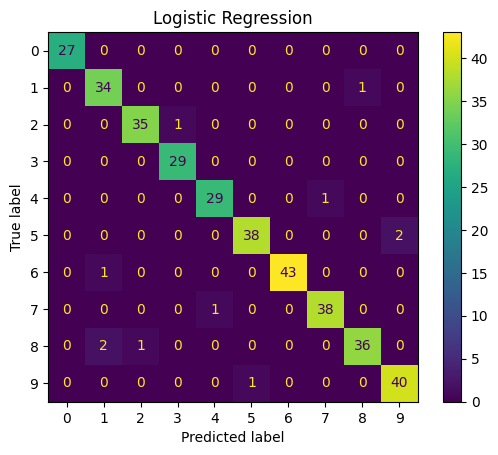

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        27
           1       0.92      0.97      0.94        35
           2       0.97      0.97      0.97        36
           3       0.97      1.00      0.98        29
           4       0.97      0.97      0.97        30
           5       0.97      0.95      0.96        40
           6       1.00      0.98      0.99        44
           7       0.97      0.97      0.97        39
           8       0.97      0.92      0.95        39
           9       0.95      0.98      0.96        41

    accuracy                           0.97       360
   macro avg       0.97      0.97      0.97       360
weighted avg       0.97      0.97      0.97       360



In [8]:
digits = datasets.load_digits()
plt.imshow(digits.images[0], cmap=plt.cm.gray_r, interpolation='nearest')
plt.show()

n_samples = len(digits.images)
data = digits.images.reshape((n_samples, -1))

X_train, X_test, y_train, y_test = train_test_split(data, digits.target, test_size=0.2, random_state=0)

models = {
    "KNN": KNeighborsClassifier(n_neighbors=6),
    "Random Forest": RandomForestClassifier(random_state=0),
    "Logistic Regression": LogisticRegression(max_iter=5000),
}

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    print(f"\n--- {name} ---")
    print("Accuracy:", metrics.accuracy_score(y_test, y_pred))
    metrics.ConfusionMatrixDisplay.from_estimator(model, X_test, y_test)
    plt.title(name)
    plt.show()
    print(metrics.classification_report(y_test, y_pred))
